# 2 · Reading body language with pose estimation

Knowing *where* a hen is only gets us so far. To tell *what it's doing* we estimate its **pose** — a little skeleton of **10 anatomical keypoints**: the beak and comb on the head, four points down the neck and back to the tail, and the hock and foot of each leg.

The head points tell us when a bird lowers its head to eat or drink; the leg points describe how it stands and walks. We run a compact **YOLOv12-pose** model on a close crop of each hen (a cropped bird fills the network far better than a distant one in the full frame).

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
from pathlib import Path

# Locate the repo root (folder holding pen_config.json) and make src/ + scripts/ importable.
ROOT = Path.cwd()
for _ in range(6):
    if (ROOT / "pen_config.json").exists():
        break
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "scripts"))

import cv2, json
import numpy as np
import matplotlib.pyplot as plt

DEMO = ROOT / "output" / "demo"
DEMO.mkdir(parents=True, exist_ok=True)

SEG_MODEL  = "models/poultry-seg-yolo12s-v2.pt"
POSE_MODEL = "models/hen_pose_yolo12s_aug_v6.pt"   # the freshly retrained pose model
STEM = "20260605_141702"                            # a daytime synchronized clip
CAM0 = ROOT / "dataset/treatment1/cam0" / f"{STEM}.mp4"   # top-down
CAM1 = ROOT / "dataset/treatment1/cam1" / f"{STEM}.mp4"   # lateral

def show(img_bgr, title="", w=11):
    """Show a BGR image inline."""
    h, wd = img_bgr.shape[:2]
    plt.figure(figsize=(w, w * h / wd))
    plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)); plt.axis("off")
    if title: plt.title(title, fontsize=13)
    plt.show()

def grab(video, idx=300):
    """Read one frame from a video."""
    cap = cv2.VideoCapture(str(video)); cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, fr = cap.read(); cap.release()
    if not ok: raise RuntimeError(f"could not read frame {idx} of {video}")
    return fr


In [2]:
from ultralytics import YOLO
seg  = YOLO(SEG_MODEL)
pose = YOLO(POSE_MODEL)
print("pose model:", Path(POSE_MODEL).name)

FlashAttention is not available on this device. Using scaled_dot_product_attention instead.


pose model: hen_pose_yolo12s_aug_v6.pt


### The 10-keypoint schema
The model outputs keypoints in this fixed order. The skeleton just connects them anatomically for display.

In [3]:
# Keypoint order the model was trained on (base schema) + drawing skeleton
KP_NAMES = ["tail_base","tail_tip","left_hock","right_hock","left_foot",
            "right_foot","neck_back","middle_back","comb","beak"]
SKELETON = [(9,8),(8,6),(6,7),(7,0),(0,1),(7,2),(7,3),(2,4),(3,5)]
def region(name):
    if name in ("beak","comb"): return (0, 215, 255)       # head  - amber
    if "hock" in name or "foot" in name: return (0, 140, 255)  # legs - orange
    return (255, 140, 40)                                   # spine - blue

def draw_pose(crop, kp, ps=4):
    out = crop.copy()
    for a, b in SKELETON:
        if kp[a,2] > 0.3 and kp[b,2] > 0.3:
            cv2.line(out, tuple(kp[a,:2].astype(int)), tuple(kp[b,:2].astype(int)),
                     (210,210,210), 2, cv2.LINE_AA)
    for j,(x,y,c) in enumerate(kp):
        if c > 0.3:
            cv2.circle(out, (int(x),int(y)), ps, region(KP_NAMES[j]), -1, cv2.LINE_AA)
    return out

### Detect hens, crop them, estimate pose
We use the segmentation model to find hens, crop each one with a little padding, and run the pose model on the crop.

posed 3 hens


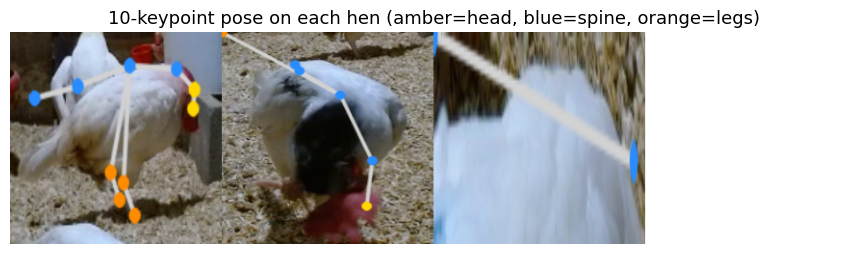

In [4]:
def crop_box(frame, box, pad=0.10):
    h, w = frame.shape[:2]
    x1, y1, x2, y2 = box
    pw, ph = (x2-x1)*pad, (y2-y1)*pad
    X1, Y1 = int(max(0, x1-pw)), int(max(0, y1-ph))
    X2, Y2 = int(min(w, x2+pw)), int(min(h, y2+ph))
    return frame[Y1:Y2, X1:X2]

frame = grab(CAM1, 300)          # lateral view shows posture best
res = seg.predict(frame, conf=0.35, imgsz=1280, verbose=False)[0]
hen_id = [k for k,v in res.names.items() if v == "hen"][0]
crops = []
for b in res.boxes:
    if int(b.cls) != hen_id: continue
    c = crop_box(frame, b.xyxy[0].cpu().numpy(), pad=0.10)
    if c.size == 0 or min(c.shape[:2]) < 20: continue
    pr = pose.predict(c, conf=0.25, verbose=False)[0]
    if pr.keypoints is None or len(pr.boxes) == 0: continue
    kp = pr.keypoints.data.cpu().numpy()[int(pr.boxes.conf.argmax())]
    crops.append(draw_pose(c, kp))
print(f"posed {len(crops)} hens")

# montage the posed crops
tiles = [cv2.resize(c, (220, 220)) for c in crops[:8]]
while len(tiles) % 4: tiles.append(np.full((220,220,3), 255, np.uint8))
rows = [np.hstack(tiles[i:i+4]) for i in range(0, len(tiles), 4)]
montage = np.vstack(rows) if rows else frame
cv2.imwrite(str(DEMO / "pose_montage.png"), montage)
show(montage, "10-keypoint pose on each hen (amber=head, blue=spine, orange=legs)")

### From keypoints to behaviour
These skeletons are the raw material for behaviour: a **head keypoint dipping toward the feeder or waterer** signals feeding or drinking, and the **leg keypoints** let us tell an alert, standing bird from one that is resting. That's the bridge to the last two notebooks.

Saved to `output/demo/pose_montage.png`.